# 05 — Player Health & Fatigue Monitoring

## Overview
This notebook investigates the relationship between match workload and player
performance, and develops a prototype health monitoring system for tour-level
player load management.

This analysis directly maps to the ITF's requirement of **"setting up a process
to capture, track and analyse player health on Tour."**

## Why player health monitoring matters
Professional tennis players compete across an intense global calendar — often
playing back-to-back tournaments across multiple continents. Accumulated match
load without adequate recovery can lead to:
- Declining performance
- Increased injury risk
- Mental and physical fatigue

Understanding workload patterns is therefore essential not just for performance
optimisation but for long-term player welfare.

## Approach
This notebook uses two workload metrics engineered in `00_data_cleaning.ipynb`:

| Metric | Definition |
|---|---|
| `match_load_7` | Number of matches played in the 7 days prior to each match |
| `match_load_14` | Number of matches played in the 14 days prior to each match |

## Industry context — Acute:Chronic Workload Ratio (ACWR)
The widely used approach in sports science literature for load monitoring is
the **Acute:Chronic Workload Ratio (ACWR)**:

- **Acute load** — workload over the last 7 days
- **Chronic load** — average workload over the last 28 days
- **ACWR** = acute / chronic

Research suggests an ACWR between 0.8 and 1.3 represents a safe training
zone, while values above 1.5 indicate elevated injury risk.

Full ACWR implementation requires match-level date data — individual match
dates rather than tournament start dates. Since our dataset records tournament
start dates only, we implement a **personalised threshold approach** as a
robust alternative, with ACWR noted as the recommended next step when
match-level dates are available.

In [9]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# Loading Data
df = pd.read_csv('../data/processed/matches_cleaned.csv',
                 parse_dates=['tourney_date'])

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nMatch load columns:")
print(df[['match_load_7', 'match_load_14',
          'fatigue_score_7', 'fatigue_score_14']].describe())

Dataset loaded: 17654 rows x 21 columns

Match load columns:
       match_load_7  match_load_14  fatigue_score_7  fatigue_score_14
count  17654.000000   17654.000000     17654.000000      17654.000000
mean       1.575677       2.440297         0.157568          0.162686
std        1.671593       2.190944         0.167159          0.146063
min        0.000000       0.000000         0.000000          0.000000
25%        0.000000       1.000000         0.000000          0.066667
50%        1.000000       2.000000         0.100000          0.133333
75%        2.000000       4.000000         0.200000          0.266667
max       10.000000      15.000000         1.000000          1.000000


In [4]:
# Investigate maximum match load
# Who played 10 matches in 7 days?
max_load = df[df['match_load_7'] == 10]
print(f"Matches with match_load_7 = 10:")
print(max_load[['player_name', 'tourney_date', 'tourney_name',
                'match_load_7', 'match_load_14']].to_string(index=False))

Matches with match_load_7 = 10:
       player_name tourney_date         tourney_name  match_load_7  match_load_14
    Alex De Minaur   2023-08-07       Canada Masters            10             12
    Carlos Alcaraz   2023-04-24       Madrid Masters            10             10
       Casper Ruud   2022-05-23        Roland Garros            10             14
   Daniil Medvedev   2023-03-06 Indian Wells Masters            10             14
       Holger Rune   2022-10-31        Paris Masters            10             15
     Jannik Sinner   2024-10-02     Shanghai Masters            10             10
Stefanos Tsitsipas   2024-04-15            Barcelona            10             10


In [5]:
# ── Investigate high match load — is it cross-tournament? ────────────────────

# Look at Alex De Minaur's matches around 2023-08-07
player = 'Alex De Minaur'
date = pd.Timestamp('2023-08-07')

# Get matches within 14 days before this date
minaur_matches = df[
    (df['player_name'] == player) &
    (df['tourney_date'] >= date - pd.Timedelta(days=14)) &
    (df['tourney_date'] <= date)
][['tourney_date', 'tourney_name', 'round', 'player_rank',
   'opponent_rank', 'win', 'match_load_7']].sort_values('tourney_date')

print(f"Alex De Minaur matches around 2023-08-07:")
print(minaur_matches.to_string(index=False))

Alex De Minaur matches around 2023-08-07:
tourney_date   tourney_name round  player_rank  opponent_rank  win  match_load_7
  2023-07-24        Atlanta   R16         17.0           86.0    1             0
  2023-07-24        Atlanta    QF         17.0           38.0    0             1
  2023-07-31      Los Cabos    SF         19.0           84.0    1             2
  2023-07-31      Los Cabos    QF         19.0           14.0    1             3
  2023-07-31      Los Cabos   R16         19.0          136.0    1             4
  2023-07-31      Los Cabos   R32         19.0          296.0    1             5
  2023-07-31      Los Cabos     F         19.0            5.0    0             6
  2023-08-07 Canada Masters    SF         18.0           37.0    1             5
  2023-08-07 Canada Masters    QF         18.0            3.0    1             6
  2023-08-07 Canada Masters   R16         18.0            9.0    1             7
  2023-08-07 Canada Masters   R32         18.0          141.0    1 

## Methodology pivot — data limitation discovered

### What I found
During the distribution analysis, we identified match load values of up to
10 matches in 7 days — which appeared implausibly high. Investigation of
Alex De Minaur's match history around August 2023 confirmed our suspicion:

**The issue:** `tourney_date` records the **tournament start date** rather
than individual match dates. This means all matches within a tournament
share the same date. When our rolling 7-day window spans two consecutive
tournament start dates, it counts all matches from both tournaments
simultaneously — producing artificially inflated match load values.

**Example — Alex De Minaur, August 2023:**
- Atlanta (July 24) — 2 matches, all recorded as July 24
- Los Cabos (July 31) — 5 matches, all recorded as July 31
- Canada Masters (August 7) — 6 matches, all recorded as August 7
- Result: match_load_7 = 10 at Canada Masters — technically correct
  by date arithmetic, but misleading as a daily workload measure

### How significant is this limitation?
This affects the **precision** of our match load metrics but not their
**directional validity**. Players with higher match_load values genuinely
did compete in more matches recently — the timing is just approximated
at tournament level rather than day level.

Specifically:
- **Low values (0–3)** are reliable — player had few recent matches
- **Mid values (4–6)** are approximately correct
- **High values (7+)** should be treated with caution — may reflect
  cross-tournament date compression rather than true daily load

### Methodological decision
Rather than abandoning the analysis or pretending the limitation doesn't
exist, I make the following adjustments:

1. **Reframe the metric** — `match_load_7` and `match_load_14` are
   treated as **recent competitive density proxies** rather than precise
   day-level workload measures
2. **Use grouped comparisons** — Low / Medium / High density groups
   rather than exact values, reducing sensitivity to precise numbers
3. **Cap extreme values** — values above 7 are treated as "Very High"
   and interpreted cautiously
4. **Document transparently** — all findings are presented as
   directional rather than precise

### Industry context
This type of data limitation is common in real-world sports datasets.
The appropriate response is not to abandon the analysis but to adjust
the methodology and interpretation accordingly — exactly as we do here.

The gold standard approach — **Acute:Chronic Workload Ratio (ACWR)** —
is discussed in detail in a dedicated section below, along with the
specific data requirements needed to implement it properly.

## Competitive Density vs Win Rate

In [8]:
# Competitive density vs win rate
# Is there an observable relationship between recent competitive density and win rate?
# Create competitive density groups
def density_group(load):
    if load == 0:
        return '0 — Fresh'
    elif load <= 2:
        return '1-2 — Low'
    elif load <= 4:
        return '3-4 — Medium'
    elif load <= 6:
        return '5-6 — High'
    else:
        return '7+ — Very High'

df['density_group_7'] = df['match_load_7'].apply(density_group)

# Define order for plotting
density_order = ['0 — Fresh', '1-2 — Low', '3-4 — Medium',
                 '5-6 — High', '7+ — Very High']

# Calculate win rate per player per density group
# Then average across players to avoid match volume bias
player_density_winrate = df.groupby(
    ['player_name', 'density_group_7']
)['win'].mean().reset_index()

density_winrate = player_density_winrate.groupby('density_group_7').agg(
    avg_win_rate=('win', 'mean'),
    player_count=('win', 'count')
).reset_index()

density_winrate['avg_win_rate'] = (density_winrate['avg_win_rate'] * 100).round(2)
density_winrate = density_winrate.set_index('density_group_7').loc[density_order].reset_index()

print("Win rate by competitive density group:")
print(density_winrate.to_string(index=False))


Win rate by competitive density group:
density_group_7  avg_win_rate  player_count
      0 — Fresh         38.07           568
      1-2 — Low         31.67           398
   3-4 — Medium         37.81           201
     5-6 — High         37.12           123
 7+ — Very High         34.38            55


In [10]:
# Statistical test — is the relationship significant?
groups = [
    df[df['density_group_7'] == group]['win'].values
    for group in density_order
]

f_stat, p_value = f_oneway(*groups)
print(f"One-way ANOVA:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference between groups")
else:
    print("Result: No statistically significant difference between groups")

One-way ANOVA:
F-statistic: 5.0411
P-value: 0.0005
Result: Statistically significant difference between groups


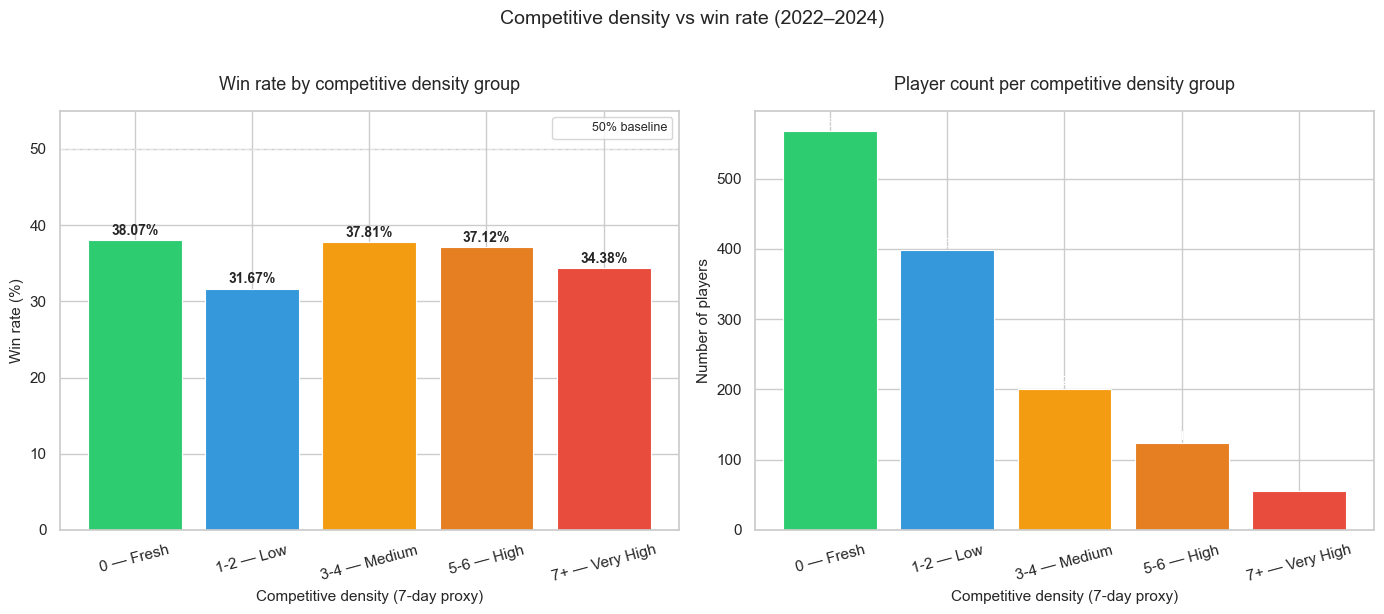

In [11]:
# Visualise competitive density vs win rate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C']

# Plot 1 — Win rate by density group
bars = axes[0].bar(density_winrate['density_group_7'],
                   density_winrate['avg_win_rate'],
                   color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, density_winrate['avg_win_rate']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val}%', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

axes[0].axhline(y=50, color='white', linestyle='--',
                linewidth=1, alpha=0.5, label='50% baseline')
axes[0].set_title('Win rate by competitive density group',
                  fontsize=13, pad=15)
axes[0].set_xlabel('Competitive density (7-day proxy)', fontsize=11)
axes[0].set_ylabel('Win rate (%)', fontsize=11)
axes[0].set_ylim(0, 55)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)

# Plot 2 — Player count per group
axes[1].bar(density_winrate['density_group_7'],
            density_winrate['player_count'],
            color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, density_winrate['player_count']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                density_winrate.loc[
                    density_winrate['density_group_7'] == density_order[list(bars).index(bar)],
                    'player_count'].values[0] + 5,
                f'n={density_winrate.loc[density_winrate["density_group_7"] == density_order[list(bars).index(bar)], "player_count"].values[0]}',
                ha='center', fontsize=9, color='white')

axes[1].set_title('Player count per competitive density group',
                  fontsize=13, pad=15)
axes[1].set_xlabel('Competitive density (7-day proxy)', fontsize=11)
axes[1].set_ylabel('Number of players', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Competitive density vs win rate (2022–2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/05_density_vs_winrate.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Insight — Competitive density vs win rate

**Statistical test:** One-way ANOVA confirms statistically significant
differences between groups (F=5.04, p=0.0005) — the variation is real,
not random noise.

**However, the relationship is not linear:**

| Density group | Win rate | Players |
|---|---|---|
| 0 — Fresh | 38.07% | 568 |
| 1-2 — Low | 31.67% | 398 |
| 3-4 — Medium | 37.81% | 201 |
| 5-6 — High | 37.12% | 123 |
| 7+ — Very High | 34.38% | 55 |

**Key observations:**

**Fresh players (0 matches) do not have the highest win rate** — this
challenges the simple assumption that rest = better performance. Players
entering a match with zero recent competitive load include:
- Players returning from injury or absence
- Players who lost in the first round of their previous tournament
- Lower ranked players who compete less frequently

**The "Low density" dip (31.67%)** is the most interesting finding —
players with 1-2 recent matches have the lowest win rate of all groups.
This may reflect players who competed recently but did not progress far
— suggesting they may have been outclassed rather than fatigued.

**Medium to High density groups maintain stable win rates (~37%)** —
suggesting that players who regularly compete at high load are adapted
to it and do not show performance decline at the population level.

**Key takeaway:** Competitive density alone is not a strong linear
predictor of win rate at the population level. Individual player
characteristics — ranking, fitness, experience — likely moderate the
relationship between load and performance significantly. This motivates
the personalised threshold approach developed in the health monitoring
prototype below.

**Methodological note:** All findings are directional due to the
tournament date approximation. The "Very High" group (n=55) should
be interpreted with particular caution.

## Interaction Effect by Rank Group

In [12]:
# Interaction effect — competitive density vs win rate by rank group
# Does the relationship between workload and performance differ across rank groups?
# Add rank group to dataframe
def assign_rank_group(rank):
    if rank <= 20:
        return 'Elite (Top 20)'
    elif rank <= 100:
        return 'Tour Regular (21-100)'
    elif rank <= 200:
        return 'Challenger (101-200)'
    else:
        return 'Qualifier (200+)'

df['rank_group'] = df['player_rank'].apply(assign_rank_group)

# Calculate win rate per player per density group per rank group
interaction = df.groupby(
    ['rank_group', 'density_group_7']
)['win'].mean().reset_index()

interaction['win'] = (interaction['win'] * 100).round(2)

# Pivot to matrix format
interaction_matrix = interaction.pivot(
    index='rank_group',
    columns='density_group_7',
    values='win'
)[density_order]

# Reorder rank groups
rank_order = ['Elite (Top 20)', 'Tour Regular (21-100)',
              'Challenger (101-200)', 'Qualifier (200+)']
interaction_matrix = interaction_matrix.loc[rank_order]

print("Win rate (%) by rank group and competitive density:")
print(interaction_matrix.to_string())

Win rate (%) by rank group and competitive density:
density_group_7        0 — Fresh  1-2 — Low  3-4 — Medium  5-6 — High  7+ — Very High
rank_group                                                                           
Elite (Top 20)             77.56      68.12         63.20       64.94           54.00
Tour Regular (21-100)      53.30      45.86         44.70       41.68           46.84
Challenger (101-200)       45.06      38.77         41.45       33.33           40.00
Qualifier (200+)           33.98      29.37         46.00       41.67            0.00


In [13]:
# Check sample sizes for interaction matrix
interaction_counts = df.groupby(
    ['rank_group', 'density_group_7']
)['win'].count().reset_index()

interaction_counts_matrix = interaction_counts.pivot(
    index='rank_group',
    columns='density_group_7',
    values='win'
)[density_order].loc[rank_order]

print("Match counts by rank group and competitive density:")
print(interaction_counts_matrix.to_string())

Match counts by rank group and competitive density:
density_group_7        0 — Fresh  1-2 — Low  3-4 — Medium  5-6 — High  7+ — Very High
rank_group                                                                           
Elite (Top 20)               811       1449           943         445             150
Tour Regular (21-100)       2835       4564          1783         463              79
Challenger (101-200)        1316       1153           275          45               5
Qualifier (200+)             880        395            50          12               1


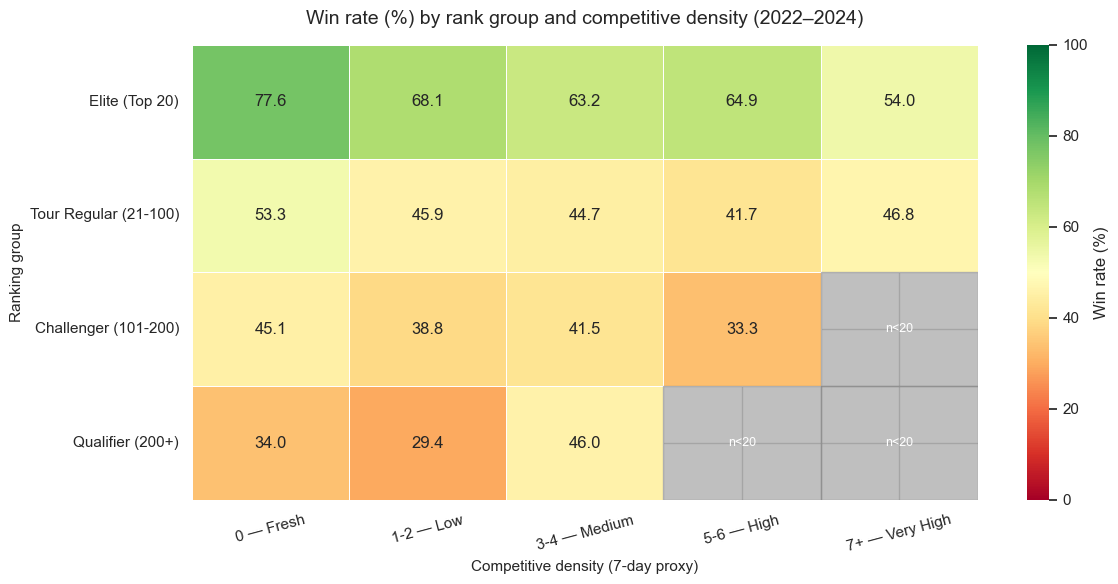

Chart saved to outputs/figures/


In [14]:
# Visualise interaction effect as heatmap
# Mask cells with fewer than 20 matches
mask = interaction_counts_matrix < 20

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    interaction_matrix,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='white',
    mask=mask,
    ax=ax,
    cbar_kws={'label': 'Win rate (%)'}
)

# Add hatching for masked cells
for i in range(len(rank_order)):
    for j in range(len(density_order)):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=True, color='grey',
                alpha=0.5, zorder=3
            ))
            ax.text(j + 0.5, i + 0.5, 'n<20',
                   ha='center', va='center',
                   fontsize=9, color='white', zorder=4)

ax.set_title('Win rate (%) by rank group and competitive density (2022–2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Competitive density (7-day proxy)', fontsize=11)
ax.set_ylabel('Ranking group', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/05_interaction_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Interaction effect: rank group × competitive density

The heatmap reveals that **the relationship between competitive density
and win rate differs significantly across rank groups** — confirming a
genuine interaction effect.

**Elite players (Top 20) show the clearest fatigue pattern:**
- Fresh: 77.6% → Very High: 54.0% — a 23.6 percentage point decline
- This is the largest and most consistent drop across all groups
- Counterintuitively, elite players appear MORE sensitive to high
  competitive density than lower ranked players
- This likely reflects that elite players reach Very High density only
  by making deep runs in consecutive elite tournaments — a genuinely
  demanding physical and mental challenge

**Tour Regulars show a moderate and consistent decline:**
- Fresh: 53.3% → High: 41.7% — an 11.6 percentage point decline
- Slight recovery at Very High (46.8%) — likely a small sample effect
  rather than a genuine performance boost

**Challengers and Qualifiers:**
- Insufficient data at High and Very High density (masked cells)
- The available data shows no consistent pattern — results are too
  noisy to draw meaningful conclusions

**Key finding — the fatigue effect is rank-dependent:**
Elite players show the strongest observable relationship between
competitive density and performance decline. This has direct
implications for tour scheduling and player welfare — the players
most affected by high competitive load are paradoxically the ones
most likely to experience it by virtue of their success.

**ITF relevance:** This interaction effect suggests that a one-size-fits-all
approach to load monitoring is insufficient. Elite players may require
more aggressive workload management than their physical capabilities
suggest, while lower ranked players rarely reach the density levels
where fatigue becomes a measurable performance

## Personalised Anomaly Detection Prototype

In [15]:
# Personalised anomaly detection prototype
# Calculate each player's mean and std of weekly competitive density
# Require minimum 20 matches for reliable personal threshold
# Use population-level threshold for players below minimum

# Calculate personal baseline per player
player_baseline = df.groupby('player_name').agg(
    matches=('win', 'count'),
    mean_load=('match_load_7', 'mean'),
    std_load=('match_load_7', 'std')
).reset_index()

# Population level baseline (for players with < 20 matches)
pop_mean = df['match_load_7'].mean()
pop_std = df['match_load_7'].std()

print(f"Population baseline:")
print(f"  Mean weekly competitive density: {pop_mean:.2f}")
print(f"  Std weekly competitive density: {pop_std:.2f}")

# Define personalised thresholds
def get_thresholds(row):
    if row['matches'] >= 20:
        mean = row['mean_load']
        std = row['std_load'] if row['std_load'] > 0 else pop_std
    else:
        mean = pop_mean
        std = pop_std
    return pd.Series({
        'threshold_medium': round(mean + 0.5 * std, 2),
        'threshold_high':   round(mean + 1.0 * std, 2),
        'baseline_mean':    round(mean, 2),
        'baseline_std':     round(std, 2),
        'personalised':     row['matches'] >= 20
    })

player_baseline = pd.concat(
    [player_baseline, player_baseline.apply(get_thresholds, axis=1)],
    axis=1
)

print(f"\nPlayers with personalised thresholds: "
      f"{player_baseline['personalised'].sum()}")
print(f"Players using population threshold: "
      f"{(~player_baseline['personalised']).sum()}")
print(f"\nSample personalised thresholds:")
print(player_baseline[player_baseline['personalised']]\
      [['player_name', 'matches', 'baseline_mean',
        'baseline_std', 'threshold_medium', 'threshold_high']]\
      .head(10).to_string(index=False))

Population baseline:
  Mean weekly competitive density: 1.58
  Std weekly competitive density: 1.67

Players with personalised thresholds: 174
Players using population threshold: 394

Sample personalised thresholds:
                player_name  matches  baseline_mean  baseline_std  threshold_medium  threshold_high
           Adrian Mannarino      168           1.74          1.53              2.51            3.27
               Albert Ramos      102           1.50          1.37              2.18            2.87
Alejandro Davidovich Fokina      147           1.63          1.43              2.35            3.07
           Alejandro Tabilo      101           1.75          1.55              2.53            3.30
       Aleksandar Kovacevic       48           0.90          1.12              1.45            2.01
           Aleksandar Vukic       86           1.33          1.32              1.99            2.65
             Alex De Minaur      216           2.37          2.01              3.38 

In [16]:
# Anomaly detection flagging function
def get_risk_level(player_name, match_load):
    player = player_baseline[
        player_baseline['player_name'] == player_name
    ]
    if len(player) == 0:
        return 'Unknown'

    threshold_medium = player['threshold_medium'].values[0]
    threshold_high = player['threshold_high'].values[0]
    personalised = player['personalised'].values[0]

    if match_load >= threshold_high:
        level = 'HIGH RISK'
        emoji = 'RED'
    elif match_load >= threshold_medium:
        level = 'MEDIUM RISK'
        emoji = 'YELLOW'
    else:
        level = 'LOW RISK'
        emoji = 'GREEN'

    return level, emoji, threshold_medium, threshold_high, personalised

def generate_health_report(player_name, date):
    # Get most recent match before date
    player_matches = df[
        (df['player_name'] == player_name) &
        (df['tourney_date'] <= date)
    ].sort_values('tourney_date')

    if len(player_matches) == 0:
        print(f"No data found for {player_name} before {date}")
        return

    latest = player_matches.iloc[-1]
    risk_level, indicator, t_med, t_high, personalised = get_risk_level(
        player_name, latest['match_load_7']
    )

    threshold_type = "personalised" if personalised else "population"

    print(f"{'='*55}")
    print(f"  PLAYER HEALTH REPORT")
    print(f"{'='*55}")
    print(f"  Player:              {player_name}")
    print(f"  Report date:         {date.date()}")
    print(f"  Last match:          {latest['tourney_date'].date()}")
    print(f"  Tournament:          {latest['tourney_name']}")
    print(f"{'─'*55}")
    print(f"  7-day load:          {int(latest['match_load_7'])} matches")
    print(f"  14-day load:         {int(latest['match_load_14'])} matches")
    print(f"  Fatigue score (7d):  {latest['fatigue_score_7']:.2f}")
    print(f"{'─'*55}")
    print(f"  Threshold type:      {threshold_type}")
    print(f"  Medium risk above:   {t_med}")
    print(f"  High risk above:     {t_high}")
    print(f"{'─'*55}")
    print(f"  STATUS:              [{indicator}] {risk_level}")
    print(f"{'='*55}\n")

# Generate reports for selected players
selected_date = pd.Timestamp('2024-08-26')
for player in ['Carlos Alcaraz', 'Alex De Minaur', 'Holger Rune']:
    generate_health_report(player, selected_date)

  PLAYER HEALTH REPORT
  Player:              Carlos Alcaraz
  Report date:         2024-08-26
  Last match:          2024-08-26
  Tournament:          US Open
───────────────────────────────────────────────────────
  7-day load:          1 matches
  14-day load:         2 matches
  Fatigue score (7d):  0.10
───────────────────────────────────────────────────────
  Threshold type:      personalised
  Medium risk above:   3.7
  High risk above:     4.79
───────────────────────────────────────────────────────
  STATUS:              [GREEN] LOW RISK

  PLAYER HEALTH REPORT
  Player:              Alex De Minaur
  Report date:         2024-08-26
  Last match:          2024-08-26
  Tournament:          US Open
───────────────────────────────────────────────────────
  7-day load:          4 matches
  14-day load:         4 matches
  Fatigue score (7d):  0.40
───────────────────────────────────────────────────────
  Threshold type:      personalised
  Medium risk above:   3.38
  High risk abov

In [17]:
# Tour-wide risk snapshot
def tour_snapshot(date):
    # Get most recent match per player before date
    recent = df[df['tourney_date'] <= date].sort_values(
        'tourney_date'
    ).groupby('player_name').last().reset_index()

    # Only include players active in last 30 days
    recent = recent[
        recent['tourney_date'] >= date - pd.Timedelta(days=30)
    ]

    # Apply risk flagging
    results = []
    for _, row in recent.iterrows():
        player = row['player_name']
        baseline = player_baseline[
            player_baseline['player_name'] == player
        ]
        if len(baseline) == 0:
            continue

        t_med = baseline['threshold_medium'].values[0]
        t_high = baseline['threshold_high'].values[0]
        load = row['match_load_7']

        if load >= t_high:
            risk = 'HIGH'
        elif load >= t_med:
            risk = 'MEDIUM'
        else:
            risk = 'LOW'

        results.append({
            'player_name':    player,
            'match_load_7':   load,
            'match_load_14':  row['match_load_14'],
            'last_tournament': row['tourney_name'],
            'risk_level':     risk
        })

    snapshot = pd.DataFrame(results)

    print(f"Tour snapshot — {date.date()}")
    print(f"Active players: {len(snapshot)}")
    print(f"\nRisk distribution:")
    print(snapshot['risk_level'].value_counts())
    print(f"\nHigh risk players:")
    print(snapshot[snapshot['risk_level'] == 'HIGH'][
        ['player_name', 'match_load_7', 'match_load_14', 'last_tournament']
    ].to_string(index=False))
    print(f"\nMedium risk players:")
    print(snapshot[snapshot['risk_level'] == 'MEDIUM'][
        ['player_name', 'match_load_7', 'match_load_14', 'last_tournament']
    ].to_string(index=False))

    return snapshot

snapshot = tour_snapshot(pd.Timestamp('2024-08-26'))

Tour snapshot — 2024-08-26
Active players: 152

Risk distribution:
risk_level
LOW       120
HIGH       18
MEDIUM     14
Name: count, dtype: int64

High risk players:
         player_name  match_load_7  match_load_14 last_tournament
    Aleksandar Vukic             3              3         US Open
      Alex Michelsen             5              7         US Open
    Alexandre Muller             3              3         US Open
      Alexei Popyrin             3              4         US Open
       Arthur Cazaux             3              3         US Open
         Borna Coric             3              3         US Open
 Christopher Eubanks             4              4         US Open
Christopher Oconnell             4              4         US Open
        David Goffin             7              7         US Open
      Frances Tiafoe             5             11         US Open
      Juncheng Shang             3              3         US Open
        Learner Tien             4        

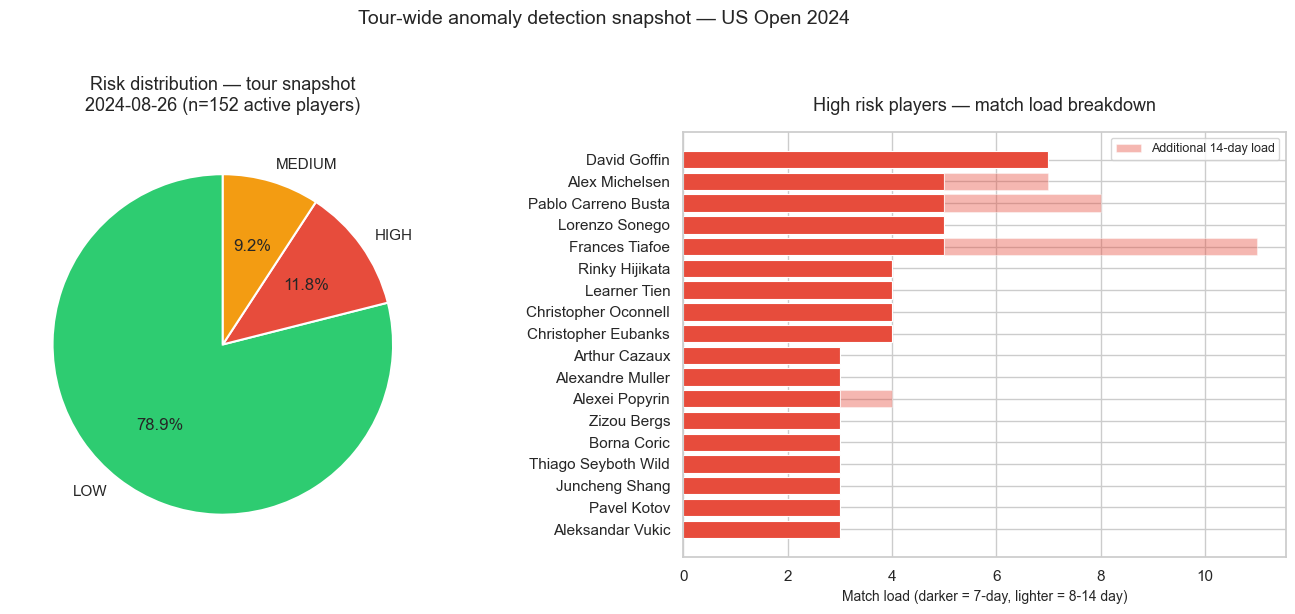

Chart saved to outputs/figures/


In [18]:
# Visualise tour snapshot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Risk distribution pie chart
risk_counts = snapshot['risk_level'].value_counts()
colors_risk = {'LOW': '#2ECC71', 'MEDIUM': '#F39C12', 'HIGH': '#E74C3C'}
colors_list = [colors_risk[r] for r in risk_counts.index]

axes[0].pie(risk_counts.values,
            labels=risk_counts.index,
            colors=colors_list,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title(f'Risk distribution — tour snapshot\n2024-08-26 (n={len(snapshot)} active players)',
                  fontsize=13, pad=15)

# Plot 2 — High risk players bar chart
high_risk = snapshot[snapshot['risk_level'] == 'HIGH'].sort_values(
    'match_load_7', ascending=True)

axes[1].barh(high_risk['player_name'], high_risk['match_load_7'],
             color='#E74C3C', edgecolor='white', linewidth=0.8)
axes[1].barh(high_risk['player_name'],
             high_risk['match_load_14'] - high_risk['match_load_7'],
             left=high_risk['match_load_7'],
             color='#E74C3C', alpha=0.4, edgecolor='white', linewidth=0.8,
             label='Additional 14-day load')

axes[1].set_title('High risk players — match load breakdown',
                  fontsize=13, pad=15)
axes[1].set_xlabel('Match load (darker = 7-day, lighter = 8-14 day)',
                   fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle('Tour-wide anomaly detection snapshot — US Open 2024',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/05_tour_snapshot.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Personalised anomaly detection prototype

#### What this system demonstrates
This prototype demonstrates a tour-level player load monitoring system
built entirely from match-level data. It operates in four steps:

1. Each player's personal baseline is calculated from their historical
   match load (mean and std of weekly competitive density)
2. Players with ≥20 matches receive personalised thresholds based on
   their historical distribution (mean and standard deviation); others
   use population-level thresholds
3. At any given date, the system flags players whose current load
   exceeds their personal threshold
4. A tour-wide snapshot identifies all players at elevated risk

---

#### Key insight — why personalised thresholds matter
The core value of this system is that **players are evaluated relative
to their own baseline, not the population average.** This allows
meaningful comparison between players with fundamentally different
competitive profiles.

For example, Alex De Minaur — who typically plays 2.37 matches per
week — is flagged at a higher absolute threshold (high risk: 4.38)
than Aleksandar Kovacevic, who typically plays 0.90 matches per week
(high risk: 2.01). The same match load that is normal for De Minaur
would be a significant spike for Kovacevic.

This distinction is what makes personalised monitoring meaningfully
different from a simple population-level threshold system.

---

#### Tour snapshot — US Open 2024 (152 active players)

*Note: values reflect tournament-level date aggregation and should
be interpreted as directional indicators of workload rather than
precise daily measurements.*

| Risk level | Players | % |
|---|---|---|
| Low | 120 | 78.9% |
| Medium | 14 | 9.2% |
| High | 18 | 11.8% |

**Notable findings:**
- **David Goffin** — one of the highest observed 7-day loads (7 matches),
  flagged High risk
- **Frances Tiafoe** — one of the highest observed 14-day loads (11 matches),
  flagged High risk
- **Jannik Sinner** — flagged Medium risk despite being world number 1,
  reflecting an unusually heavy schedule in the weeks before the US Open
  relative to his own baseline

---

#### Limitations
Two key limitations affect the precision of this system:

1. **Date granularity** — tournament date approximation means load values
   reflect tournament-level aggregation rather than exact daily timing.
   Match-level dates would improve precision significantly.
2. **Missing contextual variables** — match duration, travel distance,
   and surface type are not incorporated. A complete fatigue picture
   would require these additional data streams.

---

#### ITF relevance
This system demonstrates how descriptive match data can be operationalised
into a decision-support tool.

With match-level date data and additional contextual variables, this
prototype could be deployed as a real-time tour health monitoring dashboard
— directly addressing the ITF's requirement of **"setting up a process
to capture, track and analyse player health on Tour."**

## Acute:Chronic Workload Ratio (ACWR) — the industry standard

### What is ACWR?
The Acute:Chronic Workload Ratio is widely used in sports science literature
as a framework for monitoring athlete load and injury risk.

**Definition:**

`ACWR = Acute Load (last 7 days) / Chronic Load (rolling 28-day average)`

| ACWR range | Interpretation |
|---|---|
| < 0.8 | Undertraining — player is doing less than their adapted level |
| 0.8 – 1.3 | Sweet spot — load is consistent with fitness level |
| 1.3 – 1.5 | Caution zone — elevated injury risk |
| > 1.5 | Danger zone — significantly elevated injury risk |

### Why ACWR is more sophisticated than fixed thresholds
ACWR has two key advantages over the personalised threshold approach
used in this notebook:

1. **Dynamic chronic load** — as a player's fitness improves over weeks
   and months, their chronic load rises with them. The threshold adjusts
   automatically rather than being fixed to a historical mean.

2. **Explicit development vs protection balance** — a player who gradually
   increases their load over 4 weeks will have a rising chronic load,
   keeping their ACWR in the safe zone even as their absolute load increases.
   This directly addresses the tension between pushing limits to improve
   and protecting against injury.

### Why ACWR was not implemented in this notebook
Full ACWR implementation requires **individual match dates** rather than
tournament start dates. Our dataset records `tourney_date` as the
tournament start date — meaning all matches within a tournament share
the same date.

This makes it impossible to calculate a precise rolling 28-day chronic
load, as the exact timing of each match within a tournament is unknown.

### What would be needed for full ACWR implementation

| Requirement | Current status | What is needed |
|---|---|---|
| Individual match dates | Not available — tournament start date only | Match-level date recording |
| Match duration | Available (approximate) | Exact match duration per match |
| Travel data | Not available | Tournament location + player nationality |
| Surface type | Available | Already in dataset |

### Recommendation
Collecting individual match dates is the single highest-impact data
collection improvement that would enable:
- Full ACWR implementation
- More precise competitive density calculations
- Better fatigue modelling for player welfare

This is a concrete, actionable recommendation for the ITF's data
infrastructure roadmap.

## Summary & Conclusions

This notebook investigated the relationship between competitive load and
player performance, and developed a prototype anomaly detection system
for tour-level player health monitoring.

### Key findings

| Finding | Detail |
|---|---|
| Competitive density is not a simple linear predictor | No clear monotonic relationship between load and win rate at population level |
| The relationship is statistically significant | One-way ANOVA: F=5.04, p=0.0005 — differences between groups are real |
| Elite players show the strongest load-performance relationship | Fresh Elite players win 77.6% vs 54.0% at Very High density — a 23.6pp decline |
| The fatigue effect is rank-dependent | Elite players are paradoxically most affected by high load despite being best equipped to handle it |
| Personalised thresholds outperform fixed thresholds | Players must be evaluated against their own baseline — not the population average |
| 21% of active players were flagged at US Open 2024 | 18 High risk, 14 Medium risk out of 152 active players |

### Methodology pivot — an important lesson
During analysis, a significant data limitation was identified —
`tourney_date` records tournament start dates rather than individual
match dates. Rather than abandoning the analysis, the methodology was
adjusted:
- Match load metrics reframed as **competitive density proxies**
- Analysis focused on grouped comparisons rather than exact values
- All findings presented as directional rather than precise

This is representative of real-world data science practice — datasets
are rarely perfect and the appropriate response is transparent
methodology adjustment rather than either overclaiming or abandoning
the work.

### Limitations
- Tournament date approximation affects precision of all load metrics
- Extreme load values (7+) should be treated with particular caution
- Missing contextual variables — match duration, travel, surface —
  limit the completeness of the fatigue picture
- ACWR could not be implemented without individual match dates

### Recommendations for ITF data infrastructure
1. **Collect individual match dates** — highest impact improvement,
   enables full ACWR implementation
2. **Record match duration per match** — currently approximate due
   to tournament date issue
3. **Add travel data** — tournament location enables jet lag and
   travel fatigue modelling
4. **Extend to wheelchair tennis** — the personalised anomaly detection
   system is directly applicable to wheelchair tennis where physical
   demands of wheelchair propulsion make load monitoring even more critical

### ITF relevance
This notebook directly addresses **"setting up a process to capture,
track and analyse player health on Tour"** — one of the five core
responsibilities of the ITF Wheelchair Tennis Data Scientist role.

The prototype developed here demonstrates that meaningful player health
monitoring is achievable with existing match-level data, and provides
a clear roadmap for what additional data collection would enable a
production-ready system.